In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# UVA dataset
foreign_gifts = pd.read_csv('ForeignGifts_edu.csv', low_memory=False)
uva_gifts = foreign_gifts[foreign_gifts['Institution Name'] 
                          == 'University of Virginia'].copy()

uva_gifts.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


In [3]:
uva_gifts.describe(include='all')

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
count,98.000000,98.0,98,98,98,98.000000,9.800000e+01,98,98,98
unique,NaN,NaN,1,1,1,NaN,NaN,2,15,58
top,NaN,NaN,University of Virginia,Charlottesville,VA,NaN,NaN,Contract,ENGLAND,Kirkhouse Trust
freq,NaN,NaN,98,98,98,NaN,NaN,64,31,9
mean,26284.500000,374500.0,NaN,NaN,NaN,42671.408163,2.264208e+05,NaN,NaN,NaN
std,28.434134,0.0,NaN,NaN,NaN,521.746904,3.433051e+05,NaN,NaN,NaN
min,26236.000000,374500.0,NaN,NaN,NaN,41822.000000,3.100000e+01,NaN,NaN,NaN
25%,26260.250000,374500.0,NaN,NaN,NaN,42301.250000,9.450000e+03,NaN,NaN,NaN
50%,26284.500000,374500.0,NaN,NaN,NaN,42553.500000,8.053550e+04,NaN,NaN,NaN
75%,26308.750000,374500.0,NaN,NaN,NaN,43029.750000,2.768882e+05,NaN,NaN,NaN


In [4]:
uva_gifts['Foreign Gift Amount'].describe()

count    9.800000e+01
mean     2.264208e+05
std      3.433051e+05
min      3.100000e+01
25%      9.450000e+03
50%      8.053550e+04
75%      2.768882e+05
max      1.708021e+06
Name: Foreign Gift Amount, dtype: float64

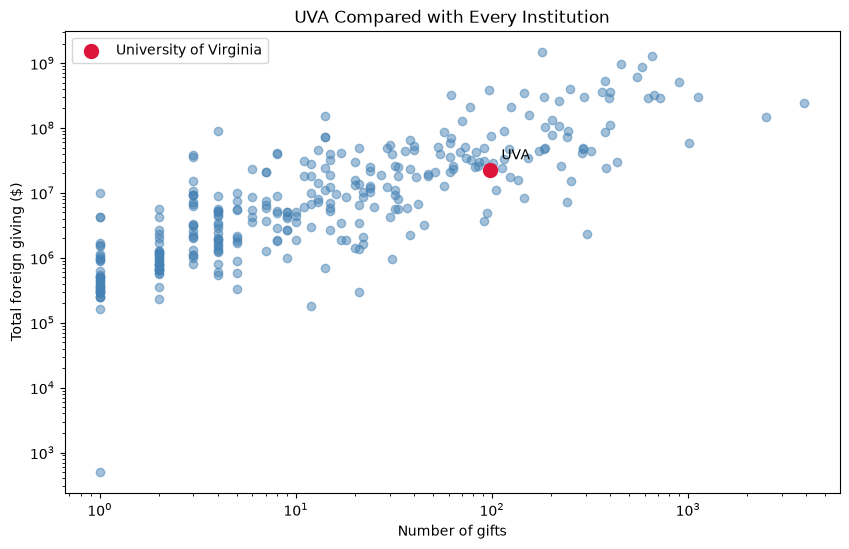

In [ ]:
# UVA vs All
foreign_gifts['Foreign Gift Amount'] = pd.to_numeric(
    foreign_gifts['Foreign Gift Amount'],
    errors='coerce'
)

institution_summary = foreign_gifts.groupby('Institution Name').agg(
    total_giving=('Foreign Gift Amount', 'sum'),
    gift_count=('Foreign Gift Amount', 'count')
)

uva_name = 'University of Virginia'

plt.figure(figsize=(10, 6))

plt.scatter(
    institution_summary['gift_count'],
    institution_summary['total_giving'],
    alpha=0.5,
    color='steelblue'
)

plt.scatter(
    institution_summary.loc[uva_name, 'gift_count'],
    institution_summary.loc[uva_name, 'total_giving'],
    color='crimson',
    s=100,
    label='University of Virginia'
)

plt.annotate(
    'UVA',
    (
        institution_summary.loc[uva_name, 'gift_count'],
        institution_summary.loc[uva_name, 'total_giving']
    ),
    xytext=(8, 8),
    textcoords='offset points'
)

plt.xlabel('Number of gifts')
plt.ylabel('Total foreign giving ($)')
plt.title('UVA Compared with Every Institution')
plt.legend()
plt.ticklabel_format(style='plain', axis='y')

plt.xscale('log')
plt.yscale('log')

plt.show()

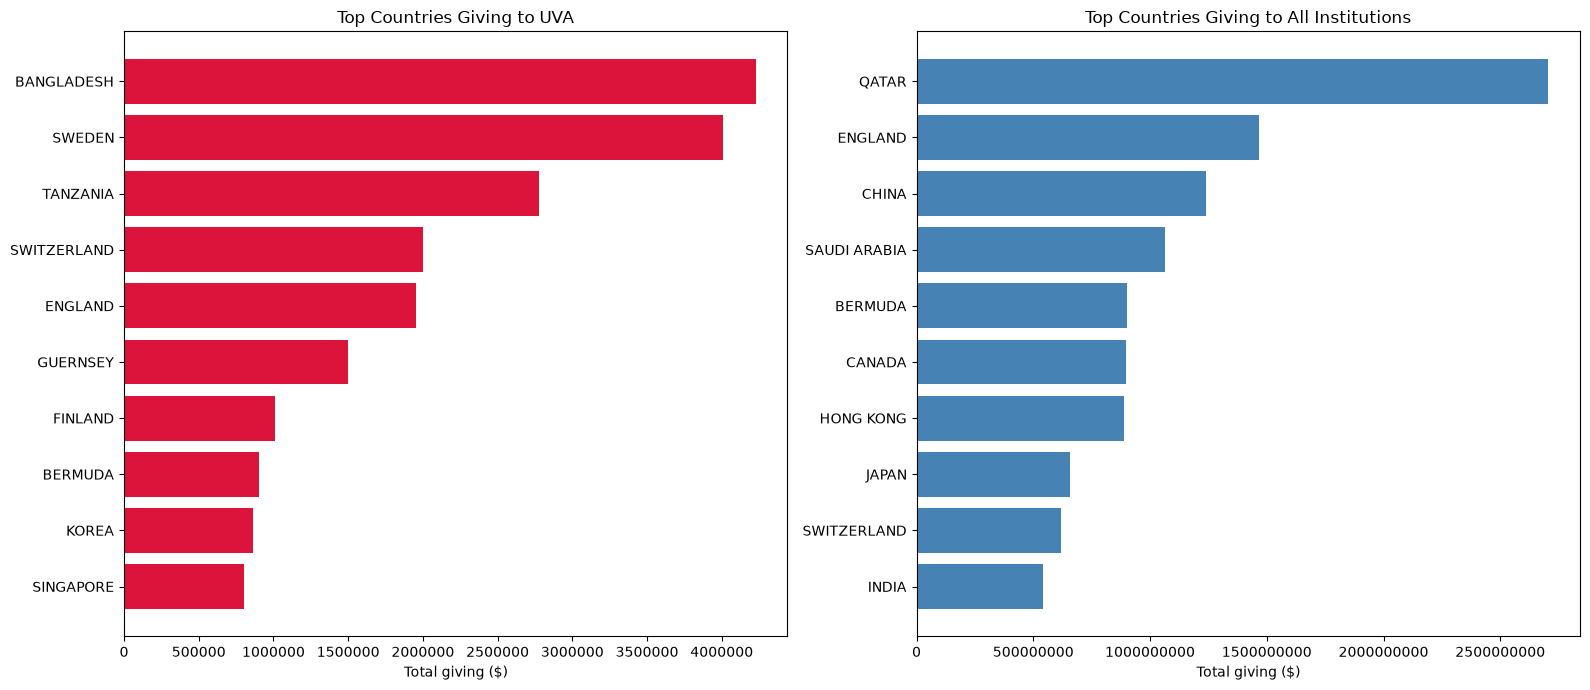

In [ ]:
# UVA top country givers vs Top country givers
uva_country_totals = (
    uva_gifts.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

overall_country_totals = (
    foreign_gifts.groupby('Country of Giftor')['Foreign Gift Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(
    uva_country_totals.index,
    uva_country_totals.values,
    color='crimson'
)
axes[0].set_title('Top Countries Giving to UVA')
axes[0].set_xlabel('Total giving ($)')
axes[0].ticklabel_format(style='plain', axis='x')

axes[1].barh(
    overall_country_totals.index,
    overall_country_totals.values,
    color='steelblue'
)
axes[1].set_title('Top Countries Giving to All Institutions')
axes[1].set_xlabel('Total giving ($)')
axes[1].ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Comparing to Peers
regional_peers = [
    'University of Virginia',
    'College of William & Mary',
    'Virginia Commonwealth University',
    'George Mason University',
    'Virginia Polytechnic Institute & State University',
    'University of North Carolina - Chapel Hill',
    'Duke University',
    'Williams College',
    'Johns Hopkins University',
    'University of Maryland, College Park'
]

regional_comparison = (
    foreign_gifts[
        foreign_gifts['Institution Name'].isin(regional_peers)
    ]
    .groupby('Institution Name')
    .agg(
        total_giving=('Foreign Gift Amount', 'sum'),
        gift_count=('Foreign Gift Amount', 'count'),
        average_gift=('Foreign Gift Amount', 'mean'),
        median_gift=('Foreign Gift Amount', 'median'),
        countries=('Country of Giftor', 'nunique')
    )
    .sort_values('total_giving', ascending=False)
)

regional_comparison.round(2)

,total_giving,gift_count,average_gift,median_gift,countries
Institution Name,,,,,
Johns Hopkins University,502409595,899,558853.83,110145.0,115
Duke University,343699498,145,2370341.37,566606.0,31
Virginia Commonwealth University,89163583,115,775335.50,33750.0,23
Williams College,73110507,14,5222179.07,1037500.0,4
George Mason University,65435604,38,1721989.58,507053.5,10
University of North Carolina - Chapel Hill,41292544,286,144379.52,33548.0,20
"University of Maryland, College Park",29933278,86,348061.37,194287.5,19
University of Virginia,22189238,98,226420.80,80535.5,15
Virginia Polytechnic Institute & State University,11792062,24,491335.92,350000.0,14


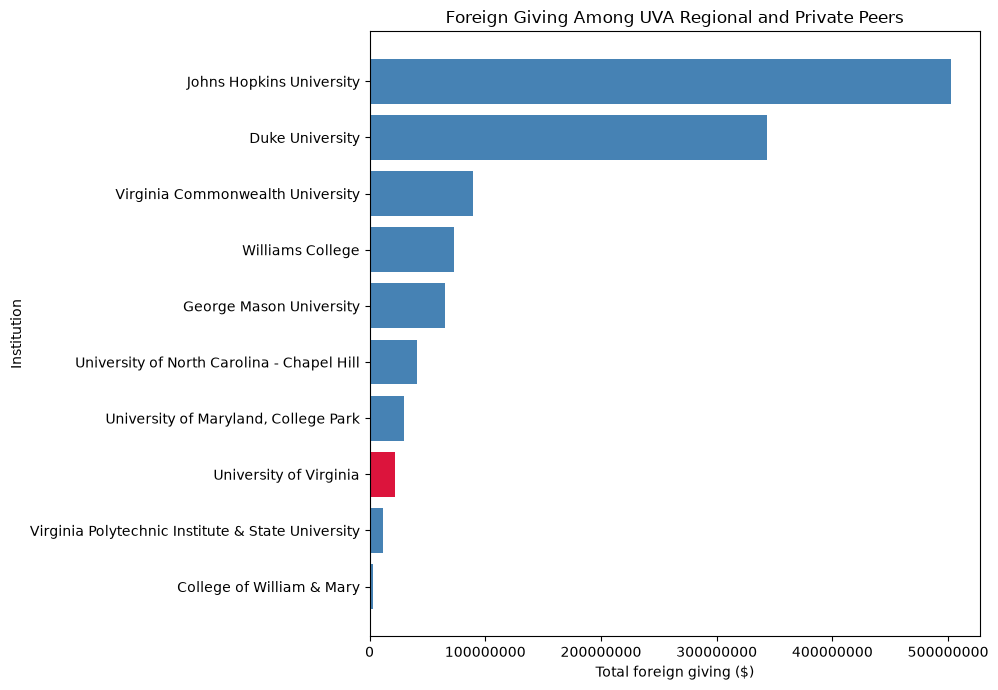

In [ ]:
# Graphing the Peers
graph_data = regional_comparison.sort_values('total_giving')

colors = [
    'crimson' if school == 'University of Virginia'
    else 'steelblue'
    for school in graph_data.index
]

plt.figure(figsize=(10, 7))

plt.barh(
    graph_data.index,
    graph_data['total_giving'],
    color=colors
)

plt.xlabel('Total foreign giving ($)')
plt.ylabel('Institution')
plt.title('Foreign Giving Among UVA Regional and Private Peers')
plt.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# UVA vs Top Institutions
institution_comparison = foreign_gifts.groupby('Institution Name').agg(
    total_giving=('Foreign Gift Amount', 'sum'),
    gift_count=('Foreign Gift Amount', 'count'),
    average_gift=('Foreign Gift Amount', 'mean'),
    median_gift=('Foreign Gift Amount', 'median'),
    countries=('Country of Giftor', 'nunique')
)

top_institutions = (
    institution_comparison
    .sort_values('gift_count', ascending=False)
    .head(10)
)

uva_row = institution_comparison.loc[['University of Virginia']]

comparison = pd.concat([top_institutions, uva_row])
comparison = comparison[~comparison.index.duplicated(keep='first')]

comparison.sort_values('gift_count', ascending=False).round(2)

,total_giving,gift_count,average_gift,median_gift,countries
Institution Name,,,,,
"University of California, Los Angeles",242146363,3916,61835.13,250.0,37
California Institute of Technology,150183084,2502,60025.21,5417.0,28
Columbia University in the City of New York,295506012,1127,262205.87,127000.0,56
Ohio State University (The),58277670,1014,57473.05,8040.0,21
Johns Hopkins University,502409595,899,558853.83,110145.0,115
University of Michigan - Ann Arbor,287336783,715,401869.63,200000.0,42
Stanford University,319561362,668,478385.27,195241.5,32
Cornell University,1289937761,653,1975402.39,250000.0,42
University of Pennsylvania,292730761,625,468369.22,289045.0,40
